# 03 — Baseline vs. Signal Model

Two questions, two models:
- **CTR/engagement signals**: which content/technical signals associate
  with CTR at a given position? (linear model, interpretable coefficients)
- **Movement**: which signals associate with forward position improvement?
  (baseline: single-feature logistic regression vs. a gradient-boosted
  model on the full signal set)

The split used here is **time-aware** (train on earlier weeks, evaluate on
later weeks the model has never seen) — see notebook 04 for the
complementary grouped-by-page leakage check.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.inspection import permutation_importance
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

plt.rcParams["figure.dpi"] = 110
df = pd.read_parquet("data/model_table.parquet")

numeric_cols = [
    "log_word_count", "has_schema_markup", "num_internal_links", "num_external_links",
    "days_since_last_update", "mobile_friendly_score", "page_speed_score",
    "title_len_deviation", "meta_description_length", "h1_count", "image_count",
    "alt_text_coverage", "readability_score", "links_per_1000_words", "week",
]
categorical_cols = ["vertical"]

## Time-aware split
Train: weeks 0–14 · Validation: weeks 15–17 · Test: weeks 18–21
(weeks 22–25 have no label — dropped in notebook 02, they're the forward
window for the last labeled rows).

In [2]:
train = df[df["week"] <= 14]
val = df[(df["week"] > 14) & (df["week"] <= 17)]
test = df[df["week"] > 17]
print(f"Train: {len(train):,} | Val: {len(val):,} | Test: {len(test):,}")

Train: 13,500 | Val: 2,700 | Test: 3,600


## Part A — CTR signal model (linear, interpretable)

CTR model R^2 on held-out (future) weeks: 0.127


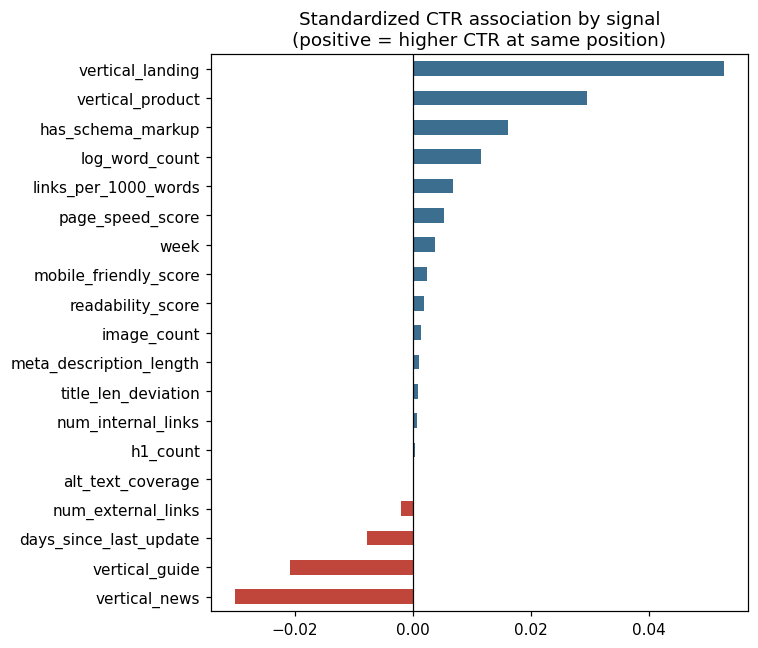

In [3]:
ctr_pre = ColumnTransformer([
    ("num", StandardScaler(), numeric_cols),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_cols),
])
ctr_pipe = Pipeline([("pre", ctr_pre), ("model", LinearRegression())])
ctr_pipe.fit(train[numeric_cols + categorical_cols], train["ctr"])

feat_names = numeric_cols + list(
    ctr_pipe.named_steps["pre"].named_transformers_["cat"].get_feature_names_out(categorical_cols)
)
ctr_coefs = pd.Series(ctr_pipe.named_steps["model"].coef_, index=feat_names).sort_values()
ctr_r2_test = ctr_pipe.score(test[numeric_cols + categorical_cols], test["ctr"])
print(f"CTR model R^2 on held-out (future) weeks: {ctr_r2_test:.3f}")

fig, ax = plt.subplots(figsize=(7, 6))
ctr_coefs.plot.barh(ax=ax, color=["#C0453B" if c < 0 else "#3B6E8F" for c in ctr_coefs])
ax.set_title("Standardized CTR association by signal\n(positive = higher CTR at same position)")
ax.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.savefig("../paper/assets/03_ctr_signal_coefficients.png", bbox_inches="tight")
plt.show()

## Part B — Movement model: baseline vs. full signal model

In [4]:
X_train, y_train = train[numeric_cols + categorical_cols], train["position_improved"]
X_val, y_val = val[numeric_cols + categorical_cols], val["position_improved"]
X_test, y_test = test[numeric_cols + categorical_cols], test["position_improved"]

# --- Baseline: single feature (days_since_last_update only), matches the
#     naive "just look at freshness" heuristic a stakeholder might already use.
baseline_pre = ColumnTransformer([("num", StandardScaler(), ["days_since_last_update"])])
baseline_pipe = Pipeline([("pre", baseline_pre), ("model", LogisticRegression())])
baseline_pipe.fit(train[["days_since_last_update"]], y_train)
baseline_test_proba = baseline_pipe.predict_proba(test[["days_since_last_update"]])[:, 1]
baseline_auc = roc_auc_score(y_test, baseline_test_proba)
baseline_ap = average_precision_score(y_test, baseline_test_proba)

# --- Full signal model
full_pre = ColumnTransformer([
    ("num", StandardScaler(), numeric_cols),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_cols),
])
full_pipe = Pipeline([
    ("pre", full_pre),
    ("model", HistGradientBoostingClassifier(max_depth=4, learning_rate=0.06, max_iter=250, random_state=0)),
])
full_pipe.fit(X_train, y_train)

# pick iteration count on validation (simple early-stop proxy) then score on test once
val_auc = roc_auc_score(y_val, full_pipe.predict_proba(X_val)[:, 1])
full_test_proba = full_pipe.predict_proba(X_test)[:, 1]
full_auc = roc_auc_score(y_test, full_test_proba)
full_ap = average_precision_score(y_test, full_test_proba)

print(f"Baseline (freshness-only)  — test AUC: {baseline_auc:.3f} | test AP: {baseline_ap:.3f}")
print(f"Full signal model          — val AUC:  {val_auc:.3f}")
print(f"Full signal model          — test AUC: {full_auc:.3f} | test AP: {full_ap:.3f}")
print(f"Base rate (share improved) in test: {y_test.mean():.3f}")

Baseline (freshness-only)  — test AUC: 0.492 | test AP: 0.130
Full signal model          — val AUC:  0.534
Full signal model          — test AUC: 0.531 | test AP: 0.151
Base rate (share improved) in test: 0.129


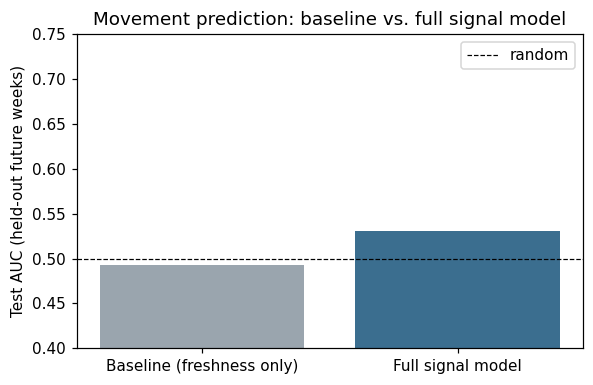

,model,test_AUC,test_AP
0,Baseline (freshness only),0.492475,0.129589
1,Full signal model,0.530704,0.150934


In [5]:
results = pd.DataFrame({
    "model": ["Baseline (freshness only)", "Full signal model"],
    "test_AUC": [baseline_auc, full_auc],
    "test_AP": [baseline_ap, full_ap],
})
fig, ax = plt.subplots(figsize=(5.5, 3.6))
ax.bar(results["model"], results["test_AUC"], color=["#9AA5AE", "#3B6E8F"])
ax.axhline(0.5, color="black", linestyle="--", linewidth=0.8, label="random")
ax.set_ylim(0.4, max(0.75, full_auc + 0.05))
ax.set_ylabel("Test AUC (held-out future weeks)")
ax.set_title("Movement prediction: baseline vs. full signal model")
ax.legend()
plt.tight_layout()
plt.savefig("../paper/assets/03_model_vs_baseline.png", bbox_inches="tight")
plt.show()
results

## Feature importance (permutation, on held-out test weeks)

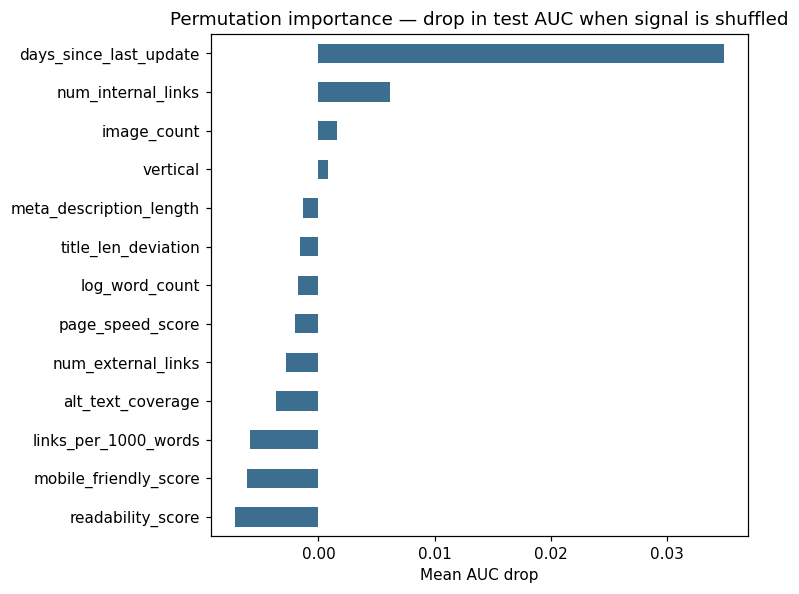

In [6]:
perm = permutation_importance(full_pipe, X_test, y_test, n_repeats=10, random_state=0, scoring="roc_auc")
imp = pd.Series(perm.importances_mean, index=numeric_cols + categorical_cols).sort_values()
imp = imp[imp.abs() > 0.0005]

fig, ax = plt.subplots(figsize=(7, 5.5))
imp.plot.barh(ax=ax, color="#3B6E8F")
ax.set_title("Permutation importance — drop in test AUC when signal is shuffled")
ax.set_xlabel("Mean AUC drop")
plt.tight_layout()
plt.savefig("../paper/assets/03_permutation_importance.png", bbox_inches="tight")
plt.show()

In [7]:
import json
with open("data/model_metrics.json", "w") as f:
    json.dump({
        "baseline_auc": round(float(baseline_auc), 4),
        "baseline_ap": round(float(baseline_ap), 4),
        "full_auc": round(float(full_auc), 4),
        "full_ap": round(float(full_ap), 4),
        "val_auc": round(float(val_auc), 4),
        "test_base_rate": round(float(y_test.mean()), 4),
        "ctr_r2_test": round(float(ctr_r2_test), 4),
        "n_train": int(len(train)), "n_val": int(len(val)), "n_test": int(len(test)),
    }, f, indent=2)
print("Saved metrics for the capstone paper.")

Saved metrics for the capstone paper.
